<a href="https://colab.research.google.com/github/srdataml-droid/AI-diploma/blob/main/week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TechieVersity  |  AI/ML Diploma  |  Week 3 Challenge

Week 3 Challenge Brief
“Is This Malaria or Not?” A Disease Diagnosis Predictor

The Real Problem
Every day, clinics in rural Nigeria and across Sub Saharan Africa miss malaria cases because lab tests are not always available. Imagine if a clinic worker could enter a few simple symptoms into a phone and instantly know whether the patient likely has malaria. That is what you are building this week. Your model could quietly save lives in communities that need it most.
Dataset
Head over to Kaggle and search for a malaria disease classification dataset. Pick one that has clinical features like temperature, age, headache, and chills.
What To Do In Google Colab
Load the data and get familiar with it. How many of the cases are actually malaria? Is the data balanced or skewed?
Clean it up. Fill missing values, encode the symptom columns, and prepare everything for training.
Train three different classifiers. Try Logistic Regression, Random Forest, and KNN. See which one understands your data best.
Evaluate carefully. Look at the confusion matrix, precision, recall, and F1 score. Pay close attention to recall this time, because missing a sick patient is far more costly than a false alarm.
Tell the story. In a markdown cell, answer this: Which symptoms most strongly point to malaria, and why does recall matter more than precision in a healthcare setting?
Targets and Submission
What	Details
Success target	Recall above 0.80 on the malaria positive class
Time limit	3 to 4 hours of focused work
Submission	Push your Colab notebook to GitHub and share the link before the next session

One thing to remember: In healthcare, missing a sick patient is far worse than a false alarm. That is why recall matters more than overall accuracy here. Build your model with that in mind.


TechieVersity  •  If it is not on GitHub, it did not happen  •  See you in the next session

 recall this time, because missing a sick patient is far more costly than a false alarm.

In [ ]:
from google.colab import files
uploaded = files.upload()  # opens a file picker

import pandas as pd
df = pd.read_csv('Malaria_Dataset.csv')
df.head()

Saving Malaria_Dataset.csv to Malaria_Dataset (1).csv


,IP_Number,Age,Sex,Residence_Area,DOA,Discharge_Date,Fever,Headache,Abdominal_Pain,General_Body_Malaise,...,Vomiting,Confusion,Backache,Chest_Pain,Coughing,Joint_Pain,Primary_Code,Diagnosis_Type,Target,Risk_Score
0,14xxxx31,52,Female,Mangalore,31-10-2015 20:42,05-11-2015 05:16,0,0,0,1,...,0,0,1,0,0,0,B50.9,Mixed Malaria Infection,0,3
1,28xxxx34,75,Female,Shimoga,03-02-2015 23:28,13-02-2015 19:27,1,0,1,1,...,0,1,0,1,1,1,B50.9,Mixed Malaria Infection,1,11
2,96xxxx43,30,Female,Mangalore,15-11-2019 12:31,19-11-2019 14:31,1,1,1,1,...,0,1,1,1,0,1,B50.9,Mixed Malaria Infection,1,13
3,49xxxx87,89,Female,Mangalore,17-05-2017 17:50,23-05-2017 13:22,0,0,0,0,...,1,1,1,1,0,1,B54,Plasmodium vivax Malaria without complication,0,5
4,48xxxx10,62,Male,Shimoga,26-06-2015 15:29,27-06-2015 23:35,0,1,0,1,...,1,1,0,0,0,0,B51.0,Plasmodium falciparum Malaria without complica...,1,8


In [ ]:
df.columns #find out more about why a data type is obj

Index(['IP_Number', 'Age', 'Sex', 'Residence_Area', 'DOA', 'Discharge_Date',
       'Fever', 'Headache', 'Abdominal_Pain', 'General_Body_Malaise',
       'Dizziness', 'Vomiting', 'Confusion', 'Backache', 'Chest_Pain',
       'Coughing', 'Joint_Pain', 'Primary_Code', 'Diagnosis_Type', 'Target',
       'Risk_Score'],
      dtype='object')

In [ ]:
df = df.drop(columns = {"IP_Number" , "Discharge_Date" , "Primary_Code" , "DOA" , "Risk_Score", "Diagnosis_Type"})
df.head(1)

,Age,Sex,Residence_Area,Fever,Headache,Abdominal_Pain,General_Body_Malaise,Dizziness,Vomiting,Confusion,Backache,Chest_Pain,Coughing,Joint_Pain,Target
0,52,Female,Mangalore,0,0,0,1,0,0,0,1,0,0,0,0


In [ ]:
df.describe()

,Age,Fever,Headache,Abdominal_Pain,General_Body_Malaise,Dizziness,Vomiting,Confusion,Backache,Chest_Pain,Coughing,Joint_Pain,Target
count,1622.000000,1622.000000,1622.000000,1622.000000,1622.000000,1622.000000,1622.000000,1622.000000,1622.000000,1622.000000,1622.000000,1622.000000,1622.000000
mean,44.705302,0.474723,0.507398,0.496917,0.479038,0.504316,0.500000,0.479655,0.509864,0.500617,0.483970,0.511714,0.719482
std,26.025626,0.499515,0.500099,0.500145,0.499714,0.500136,0.500154,0.499740,0.500057,0.500154,0.499897,0.500017,0.449391
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,22.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,44.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.500000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000
75%,68.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,89.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1622 entries, 0 to 1621
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Age                   1622 non-null   int64 
 1   Sex                   1622 non-null   object
 2   Residence_Area        1622 non-null   object
 3   Fever                 1622 non-null   int64 
 4   Headache              1622 non-null   int64 
 5   Abdominal_Pain        1622 non-null   int64 
 6   General_Body_Malaise  1622 non-null   int64 
 7   Dizziness             1622 non-null   int64 
 8   Vomiting              1622 non-null   int64 
 9   Confusion             1622 non-null   int64 
 10  Backache              1622 non-null   int64 
 11  Chest_Pain            1622 non-null   int64 
 12  Coughing              1622 non-null   int64 
 13  Joint_Pain            1622 non-null   int64 
 14  Target                1622 non-null   int64 
dtypes: int64(13), object(2)
memory usage: 

No null so getting into the import aspect of importation


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Text(0.5, 1.0, 'Malaria case distribution')

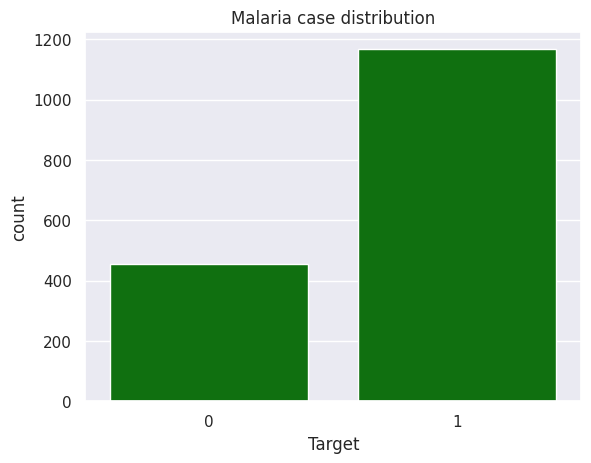

In [ ]:
from typing import Any
sns.countplot( x = "Target", data = df, color = "green")
sns.set_theme(style = "darkgrid")
plt.title('Malaria case distribution')
# plt.show() # plt.legend()

In [ ]:
# no_malaria = df[df['target'] == 0]
# malaria = df[df['target'] == 1]
age = df.Age.unique()
no_malaria = df[df['Target'] == 0]
malaria = df[df['Target'] == 1]

In [ ]:
age

array([52, 75, 30, 89, 62,  7, 53, 78, 54, 48, 82, 15, 11, 41, 88,  4, 71,
       28,  3, 24, 58, 59,  2, 17, 16, 36, 40, 31, 19, 72, 18, 68, 33, 51,
       69, 46, 50,  8, 32, 47, 23, 22, 84, 12, 74, 83,  5, 66, 44,  1, 63,
       35, 49, 79, 38, 55, 67, 86,  6, 70, 14, 27, 60, 57, 29, 25, 80, 26,
       10, 43, 45, 77, 76, 87,  9, 20, 61, 39, 13, 21, 73, 81, 42, 85, 64,
       65, 34, 37, 56])

In [ ]:
malaria.count()

,0
Age,1167
Sex,1167
Residence_Area,1167
Fever,1167
Headache,1167
Abdominal_Pain,1167
General_Body_Malaise,1167
Dizziness,1167
Vomiting,1167
Confusion,1167


In [ ]:
malaria_downsampled = malaria.sample(n=len(no_malaria), random_state=42)

# put them back together and shuffle
df_balanced = pd.concat([no_malaria, malaria_downsampled]).sample(frac=1, random_state=42)

<Axes: xlabel='Target', ylabel='count'>

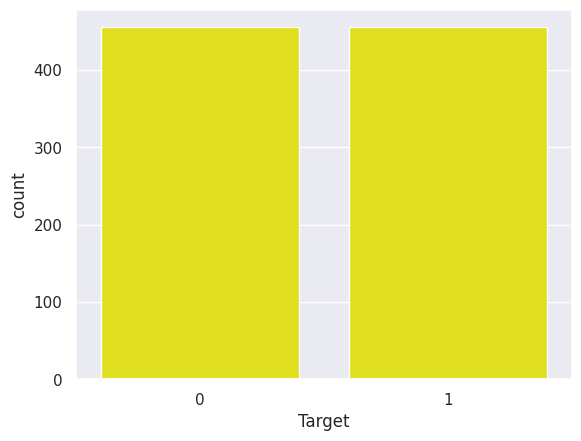

In [ ]:
sns.countplot( x= "Target" , data = df_balanced , color = "yellow")

In [ ]:
df_balanced.info()

<class 'pandas.core.frame.DataFrame'>
Index: 910 entries, 1149 to 372
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Age                   910 non-null    int64 
 1   Sex                   910 non-null    object
 2   Residence_Area        910 non-null    object
 3   Fever                 910 non-null    int64 
 4   Headache              910 non-null    int64 
 5   Abdominal_Pain        910 non-null    int64 
 6   General_Body_Malaise  910 non-null    int64 
 7   Dizziness             910 non-null    int64 
 8   Vomiting              910 non-null    int64 
 9   Confusion             910 non-null    int64 
 10  Backache              910 non-null    int64 
 11  Chest_Pain            910 non-null    int64 
 12  Coughing              910 non-null    int64 
 13  Joint_Pain            910 non-null    int64 
 14  Target                910 non-null    int64 
dtypes: int64(13), object(2)
memory usage: 113.

In [ ]:
df_balanced.describe()

,Age,Fever,Headache,Abdominal_Pain,General_Body_Malaise,Dizziness,Vomiting,Confusion,Backache,Chest_Pain,Coughing,Joint_Pain,Target
count,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000,910.000000
mean,46.924176,0.384615,0.440659,0.445055,0.382418,0.451648,0.437363,0.449451,0.507692,0.501099,0.489011,0.516484,0.500000
std,26.419102,0.486772,0.496739,0.497245,0.486245,0.497930,0.496334,0.497712,0.500216,0.500274,0.500154,0.500003,0.500275
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,49.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.500000
75%,71.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,89.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df_balanced.duplicated()

,0
1149,False
1571,False
1230,False
1253,False
70,False
...,...
379,False
976,False
737,False
1560,False


In [ ]:
df_balanced = pd.get_dummies(df_balanced, columns=['Sex', 'Residence_Area'])

In [ ]:
x = df_balanced.drop(columns = "Target")
y = df_balanced.Target

import numpy as np

from sklearn.model_selection import StratifiedKFold

X = np.array([[1, 2], [3, 4], [1, 2], [3, 4]])

y = np.array([0, 0, 1, 1])

skf = StratifiedKFold(n_splits=2)

skf.get_n_splits()

2

print(skf)

StratifiedKFold(n_splits=2, random_state=None,
shuffle=False)

for i, (train_index, test_index) in enumerate(skf.split

(X, y)):

    print(f"Fold {i}:")

    print(f"  Train: index={train_index}")

    print(f"  Test:  index={test_index}")

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split , StratifiedKFold
from sklearn.metrics import f1_score, confusion_matrix, precision_score ,recall_score, accuracy_score

StratifiedKFold is a variation of k-fold cross-validation used primarily in classification problems. It ensures that each generated fold (train/test split) contains the exact same proportion of target class labels as the original dataset, which prevents biased evaluations

In [ ]:
skf = StratifiedKFold(n_splits=2)

In [ ]:
model = LogisticRegression(max_iter= 1000)
skf.split(x, y)
x_train, x_test, y_train, y_test = train_test_split(x ,y , random_state=42, train_size=0.8, stratify=y)

In [ ]:
# model.fit(x_test, y_test)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [ ]:
Accuracy = accuracy_score(y_test , y_pred)
precision = precision_score(y_test , y_pred)
recall = recall_score(y_test , y_pred)
f1 = f1_score(y_test , y_pred)
cm = confusion_matrix(y_test , y_pred)

In [ ]:
Accuracy

0.967032967032967

In [ ]:
recall

0.967032967032967

In [ ]:
f1

0.967032967032967

In [ ]:
precision

0.967032967032967

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
model_2 = RandomForestClassifier()
# model_2.fit(x_test,y_test)
model_2.fit(x_train,y_train)
y_pred = model_2.predict(x_test)

In [ ]:
Accuracy = accuracy_score(y_test , y_pred)
precision = precision_score(y_test , y_pred)
recall = recall_score(y_test , y_pred)
f1 = f1_score(y_test , y_pred)

In [ ]:
precision


0.9662921348314607

In [ ]:
recall

0.945054945054945

In [ ]:
f1

0.9555555555555556

In [ ]:
Accuracy


0.9560439560439561

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)

In [ ]:
k_values = list(range(1, 21))  # make it a proper list
f1_scores = []

In [ ]:
k_values = range(1, 21)
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)
    y_pred = knn.predict(x_test)
    f1_scores.append(f1_score(y_test, y_pred))

In [ ]:
f1_scores

[0.8117647058823529,
 0.6618705035971223,
 0.8072289156626506,
 0.7682119205298014,
 0.8352941176470589,
 0.7843137254901961,
 0.8242424242424242,
 0.7792207792207793,
 0.8343558282208589,
 0.7631578947368421,
 0.7901234567901234,
 0.7898089171974523,
 0.8242424242424242,
 0.7948717948717948,
 0.8220858895705522,
 0.7898089171974523,
 0.8125,
 0.7712418300653595,
 0.825,
 0.7631578947368421]

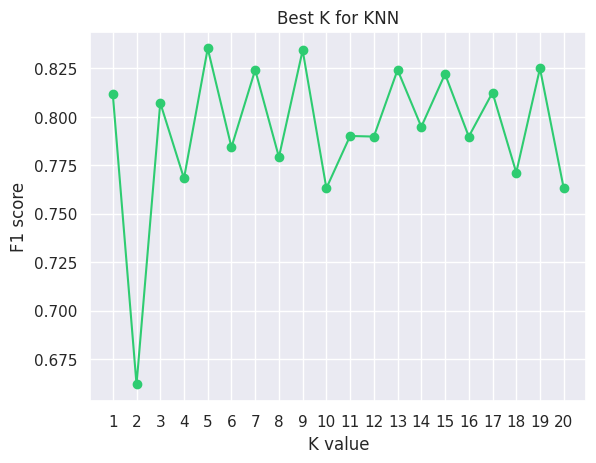

In [ ]:
plt.plot(k_values, f1_scores, color='#2ecc71', marker='o')
plt.xlabel('K value')
plt.ylabel('F1 score')
plt.title('Best K for KNN')
plt.xticks(k_values)
plt.show()

In [ ]:
best_k = k_values[f1_scores.index(max(f1_scores))]
print(f"Best K: {best_k}")

Best K: 5


In [ ]:
k = 5
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(x_train, y_train)
y_pred = knn.predict(x_test)
Accuracy = accuracy_score(y_test , y_pred)
precision = precision_score(y_test , y_pred)
recall = recall_score(y_test , y_pred)
f1 = f1_score(y_test , y_pred)

In [ ]:
f1

0.8352941176470589

In [ ]:
Accuracy

0.8461538461538461

In [ ]:
precision

0.8987341772151899

In [ ]:
recall

0.7802197802197802

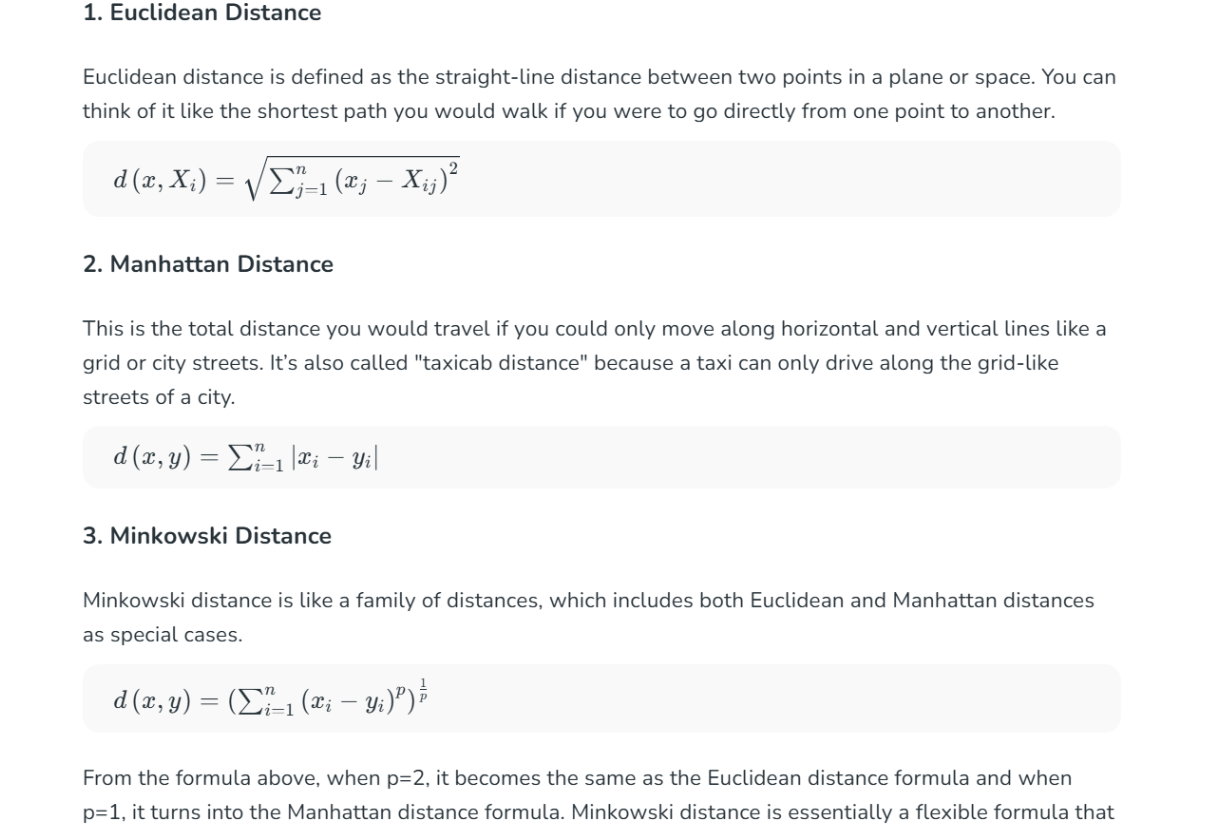


Randomforest classification

The dataset includes demographic features such as Age, Sex, and Residence Area, which help assess malaria risk in different population groups. Admission (DOA) and Discharge Dates provide temporal context for patient care. Clinical symptoms include Fever, Headache, Abdominal Pain, General Body Malaise, Dizziness, Vomiting, Confusion, Backache, Chest Pain, Coughing, and Joint Pain, which are commonly reported in malaria cases and vary in severity. Primary Code and Diagnosis Type specify the malaria classification. The Target column indicates malaria presence (1) or absence (0).


what Do you recommend sir.

handling data inbalance

"cut off"

"shuffle btw the prediction. "

cut of some part and use some to train

"data augmentation .. "..."domain knowledge."

"external dataset"


TechieVersity  |  AI/ML Diploma  |  Week 3 Challenge

Week 3 Challenge Brief
“Is This Malaria or Not?” A Disease Diagnosis Predictor

The Real Problem
Every day, clinics in rural Nigeria and across Sub Saharan Africa miss malaria cases because lab tests are not always available. Imagine if a clinic worker could enter a few simple symptoms into a phone and instantly know whether the patient likely has malaria. That is what you are building this week. Your model could quietly save lives in communities that need it most.
Dataset
Head over to Kaggle and search for a malaria disease classification dataset. Pick one that has clinical features like temperature, age, headache, and chills.
What To Do In Google Colab
Load the data and get familiar with it. How many of the cases are actually malaria? Is the data balanced or skewed?
Clean it up. Fill missing values, encode the symptom columns, and prepare everything for training.
Train three different classifiers. Try Logistic Regression, Random Forest, and KNN. See which one understands your data best.
Evaluate carefully. Look at the confusion matrix, precision, recall, and F1 score. Pay close attention to recall this time, because missing a sick patient is far more costly than a false alarm.
Tell the story. In a markdown cell, answer this: Which symptoms most strongly point to malaria, and why does recall matter more than precision in a healthcare setting?
Targets and Submission
What	Details
Success target	Recall above 0.80 on the malaria positive class
Time limit	3 to 4 hours of focused work
Submission	Push your Colab notebook to GitHub and share the link before the next session

One thing to remember: In healthcare, missing a sick patient is far worse than a false alarm. That is why recall matters more than overall accuracy here. Build your model with that in mind.


TechieVersity  •  If it is not on GitHub, it did not happen  •  See you in the next session

